CONTROLLED NEAR-RESONANCE TEST
Lattice: N=12, Base: B=9
Same initial state for all sequences: [0 1 2 3 4 5 6 7 8 0 1 2]

--- epsilon = 0.0 ---
Sequence        |  Transient |      Cycle
------------------------------------------
Fibonacci       |       6736 |          3
Lucas           |       1920 |        156
Linear          |          4 |          1
Prime gaps      |         77 |          1
All-ones        |      12040 |          6

--- epsilon = 0.5 ---
Sequence        |  Transient |      Cycle
------------------------------------------
Fibonacci       |      41005 |         77
Lucas           |      32386 |        246
Linear          |        249 |          3
Prime gaps      |         17 |          2
All-ones        |      40949 |          2

--- epsilon = 1.0 ---
Sequence        |  Transient |      Cycle
------------------------------------------
Fibonacci       |       4747 |        542
Lucas           |       3026 |       1184
Linear          |        615 |        165
Prime gaps

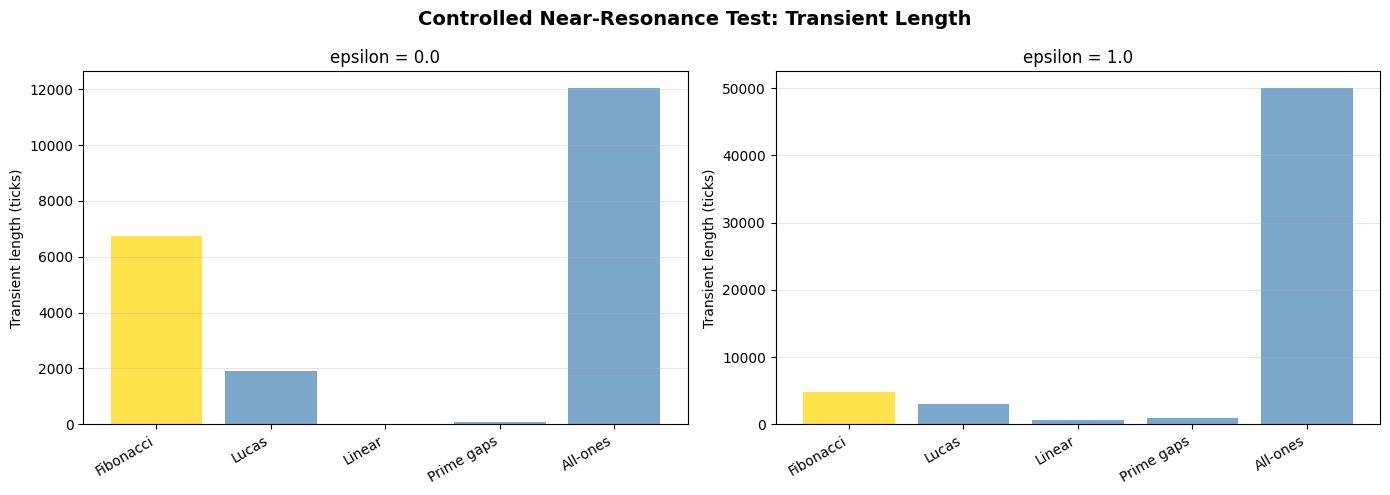

In [2]:
"""
Phi in Finitism: Controlled Near-Resonance Test
================================================
Fix:
- Same initial state for all sequences
- Near-resonant system (weak perturbation)
- Metric: transient length (ticks before entering a cycle)

Prediction: Fibonacci produces the longest transient.

By Néstor E. Ramos

"""

import numpy as np
from math import sqrt, pi

PHI = (1 + sqrt(5)) / 2
B = 9
N = 12

sequences = {
    'Fibonacci':    [1, 2, 3, 5, 3, 2, 1],
    'Lucas':        [1, 3, 4, 7, 4, 3, 1],
    'Linear':       [1, 2, 3, 4, 3, 2, 1],
    'Prime gaps':   [1, 2, 2, 4, 2, 2, 1],
    'All-ones':     [1, 1, 1, 1, 1, 1, 1],
}

def fano_step(state, weights, epsilon=0.0):
    """Automaton with optional near-resonant perturbation."""
    n = len(state)
    new_state = np.zeros_like(state)
    for i in range(n):
        indices = [(i + k) % n for k in range(-3, 4)]
        neighborhood = state[indices].astype(float)
        weighted_sum = float(np.dot(weights, neighborhood))
        # Add a weak periodic perturbation (near-resonance)
        weighted_sum += epsilon * np.sin(2 * pi * i / n)
        weighted_sum = int(round(weighted_sum))
        if weighted_sum % 7 == 0:
            new_state[i] = B - 1
        else:
            new_state[i] = weighted_sum % B
    return new_state

def transient_length(state, weights, epsilon, max_ticks=50_000):
    """Ticks before the trajectory enters a cycle."""
    seen = {}
    s = state.copy()
    for t in range(max_ticks):
        key = s.tobytes()
        if key in seen:
            return t  # transient ends when cycle begins
        seen[key] = t
        s = fano_step(s, weights, epsilon)
    return max_ticks

# Same initial state for all sequences
initial = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 0, 1, 2])

print("=" * 75)
print("CONTROLLED NEAR-RESONANCE TEST")
print("=" * 75)
print(f"Lattice: N={N}, Base: B={B}")
print(f"Same initial state for all sequences: {initial}")
print()

# Test at two perturbation levels
for epsilon in [0.0, 0.5, 1.0]:
    print(f"--- epsilon = {epsilon} ---")
    print(f"{'Sequence':<15} | {'Transient':>10} | {'Cycle':>10}")
    print("-" * 42)

    for name, weights in sequences.items():
        seen = {}
        s = initial.copy()
        cycle_start = None
        cycle_len = None
        for t in range(50_000):
            key = s.tobytes()
            if key in seen:
                cycle_start = seen[key]
                cycle_len = t - seen[key]
                break
            seen[key] = t
            s = fano_step(s, weights, epsilon)

        if cycle_start is not None:
            print(f"{name:<15} | {cycle_start:>10} | {cycle_len:>10}")
        else:
            print(f"{name:<15} | {'>50000':>10} | {'None':>10}")
    print()

# =============================================================================
# VISUALIZATION
# =============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Controlled Near-Resonance Test: Transient Length', fontsize=14, fontweight='bold')

for ax, epsilon in zip(axes, [0.0, 1.0]):
    transients = []
    names = list(sequences.keys())
    for name, weights in sequences.items():
        seen = {}
        s = initial.copy()
        cycle_start = 50_000
        for t in range(50_000):
            key = s.tobytes()
            if key in seen:
                cycle_start = seen[key]
                break
            seen[key] = t
            s = fano_step(s, weights, epsilon)
        transients.append(cycle_start)

    colors = ['gold' if n == 'Fibonacci' else 'steelblue' for n in names]
    ax.bar(range(len(names)), transients, color=colors, alpha=0.7)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right')
    ax.set_ylabel('Transient length (ticks)')
    ax.set_title(f'epsilon = {epsilon}')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phi_controlled_test.png', dpi=150, bbox_inches='tight')
plt.show()